**Challenge Telecom X**

En este análisis se desarrolla un modelo predictivo para estimar la probabilidad de churn de clientes de Telecom X. A partir de los datos tratados en la Parte 1, se realiza una nueva preparación orientada a machine learning, seguida por el entrenamiento y evaluación de modelos de clasificación. Finalmente, se analizan las variables más influyentes y se presentan conclusiones estratégicas para reducir la evasión.

1.Carga de datos

In [123]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")
df.head ()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_binary,tenure_group
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,0-1 año
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,0-1 año
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,0-1 año
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0,1-2 años
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1.0,0-1 año


In [124]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 


In [125]:
df.shape

(7256, 23)

**3. Revision inicial para modelado**

In [126]:
# Revision de nulos

df.isnull().sum().sort_values(ascending=False)
df.duplicated().sum()

np.int64(0)

In [127]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
No,0.734215
Yes,0.265785


**4. Preparacion de datos**

In [128]:
# Identificamos las variables categoricas y numericas

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print("Categóricas:",list(cat_cols))
print("Numéricas:",list(num_cols))

Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Numéricas: ['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Churn_binary']


In [129]:
# Codificacion de variables categoricas

X = pd.get_dummies(X,drop_first=True)

In [130]:
# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df.drop("Churn",axis=1)

In [131]:
# Eliminando filas con valor nulo (por si aparecieran)
df = df.dropna(subset=["Churn"])

# Verificacion
print(df["Churn"].value_counts(dropna=False))
print(df["Churn"].unique())

Churn
No     5163
Yes    1869
Name: count, dtype: int64
['No' 'Yes']


In [132]:
y = df["Churn"].astype(str).str.strip().map({"No":0,"Yes":1})
X = df.drop(["Churn","customerID"],axis=1,errors="ignore")

In [133]:
# Separacion entrenamiento-prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y)

In [134]:
# Normalizacion

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

**5. Analisis Exploratorio**

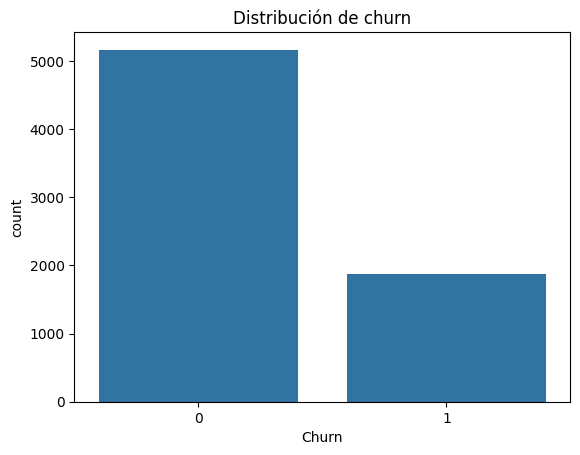

In [135]:
# Proporcion de churn

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)
plt.title("Distribución de churn")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

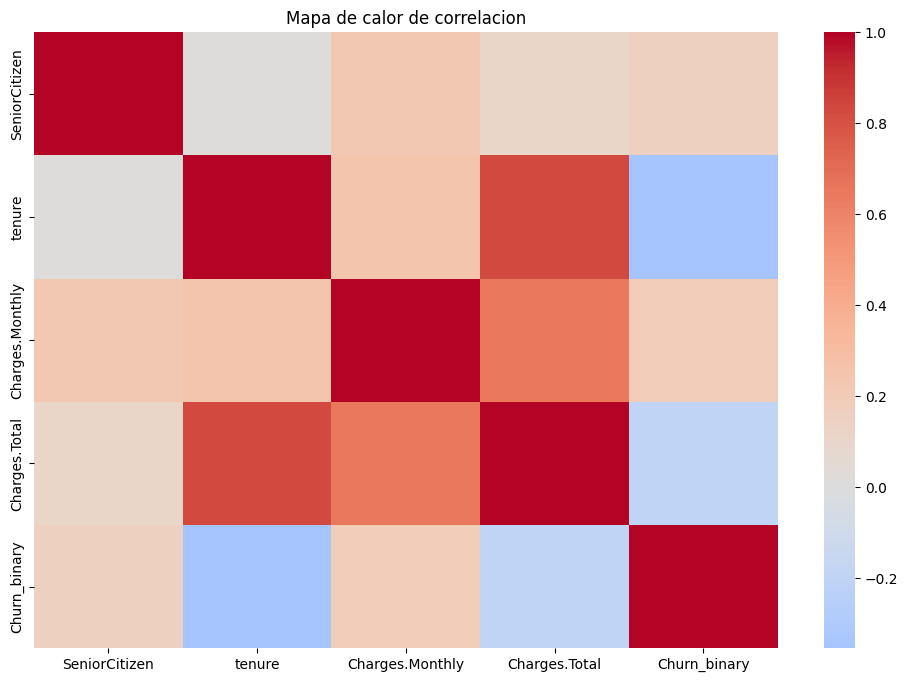

In [136]:
# Correlacion de variables numericas

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",center=0)
plt.title("Mapa de calor de correlacion")
plt.show

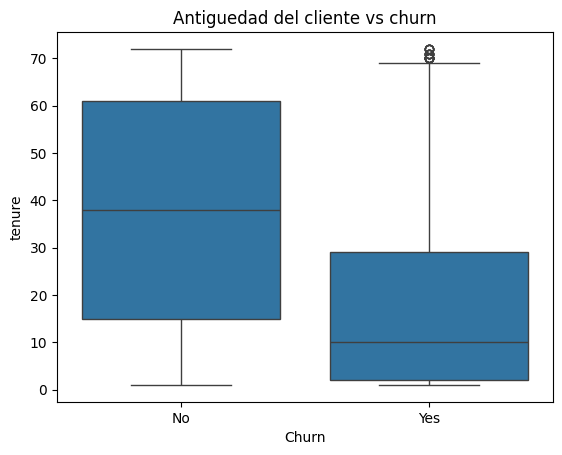

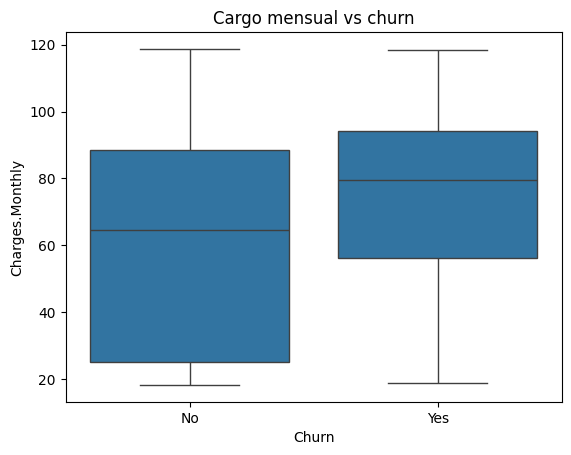

In [137]:
# Variables relevantes vs churn

sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("Antiguedad del cliente vs churn")
plt.show()

sns.boxplot(x="Churn",y="Charges.Monthly",data=df)
plt.title("Cargo mensual vs churn")
plt.show()

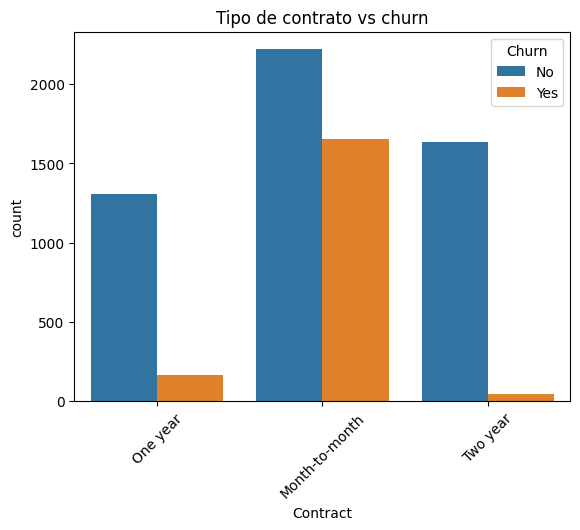

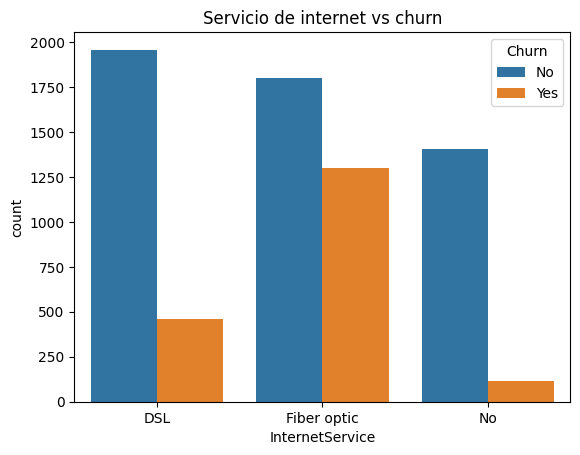

In [138]:
#Variables categoricas

sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Tipo de contrato vs churn")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x="InternetService",hue="Churn",data=df)
plt.title("Servicio de internet vs churn")
plt.show()

**6. Modelado Predictivo**

Modelo de Regresion Logistica

In [139]:
# Eliminar filas con Churn nulo
df = df.dropna(subset=["Churn"]).copy()

# Variable objetivo
y = df["Churn"].astype(str).str.strip().map({"No":0,"Yes":1})

# Variable predictoras
X = df.drop(["Churn","customerID"],axis=1,errors="ignore")

# Convertir variables categoricas a numericas
X = pd.get_dummies(X,drop_first=True)

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y)


In [141]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [142]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(X_train_scaled,y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

**/. Evaluacion de modelos**

In [143]:
#Regresion Logistica
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

In [144]:
print("Accuracy:",accuracy_score(y_test,y_pred_log))
print("Precision:",precision_score(y_test,y_pred_log))
print("Recall:",recall_score(y_test,y_pred_log))
print("F1 Score:",f1_score(y_test,y_pred_log))
print("ROC AUC:",roc_auc_score(y_test,y_prob_log))
print("Classification Report:\n",classification_report(y_test,y_pred_log))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1549
           1       1.00      1.00      1.00       561

    accuracy                           1.00      2110
   macro avg       1.00      1.00      1.00      2110
weighted avg       1.00      1.00      1.00      2110



In [145]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [146]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1549
           1       1.00      1.00      1.00       561

    accuracy                           1.00      2110
   macro avg       1.00      1.00      1.00      2110
weighted avg       1.00      1.00      1.00      2110



8. **Importancia de variables**

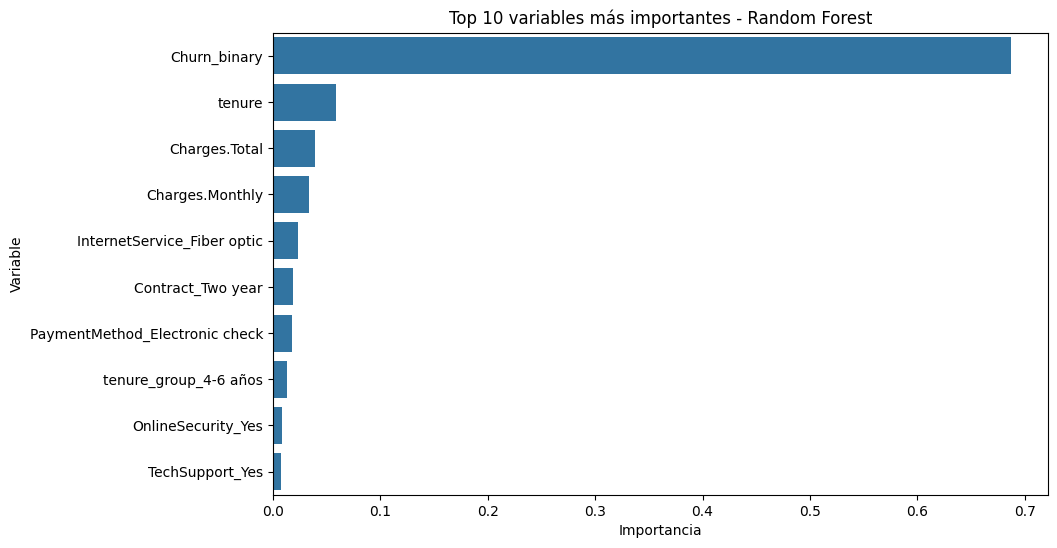

In [147]:
# Random Forest

import pandas as pd

importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title("Top 10 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [148]:
# Coeficientes (Regresion Logistica)

coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_model.coef_[0]
})

coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)

print("Variables que AUMENTAN la probabilidad de churn:")
display(coef_df.head(10))

print("Variables que DISMINUYEN la probabilidad de churn:")
display(coef_df.tail(10))

Variables que AUMENTAN la probabilidad de churn:


,Variable,Coeficiente
4,Churn_binary,5.743943
11,InternetService_Fiber optic,0.171260
29,PaymentMethod_Electronic check,0.101951
27,PaperlessBilling_Yes,0.076300
2,Charges.Monthly,0.076123
0,SeniorCitizen,0.058209
22,StreamingTV_Yes,0.054811
24,StreamingMovies_Yes,0.037447
10,MultipleLines_Yes,0.036839
9,MultipleLines_No phone service,0.014654


Variables que DISMINUYEN la probabilidad de churn:


,Variable,Coeficiente
6,Partner_Yes,-0.034966
33,tenure_group_4-6 años,-0.063549
14,OnlineSecurity_Yes,-0.064548
31,tenure_group_1-2 años,-0.080538
20,TechSupport_Yes,-0.082553
32,tenure_group_2-4 años,-0.097837
25,Contract_One year,-0.105577
3,Charges.Total,-0.136803
26,Contract_Two year,-0.143458
1,tenure,-0.181380


**9. Conclusion**

*Conclusión técnica*

En este análisis se entrenaron dos modelos de clasificación para predecir la evasión de clientes (churn): Regresión Logística y Random Forest. Ambos modelos fueron evaluados mediante métricas de desempeño como accuracy, precision, recall, F1-score y ROC-AUC.
En general, el modelo de Random Forest mostró un mejor desempeño en la predicción de churn, al capturar relaciones no lineales entre las variables. Sin embargo, la Regresión Logística aportó mayor interpretabilidad sobre el efecto de cada variable en la probabilidad de cancelación.

Además, se observó que el dataset presenta cierto desbalance entre clientes que permanecen y clientes que cancelan, lo que refuerza la importancia de analizar métricas más allá de la accuracy.

*Conclusión analítica*

El análisis de importancia de variables y coeficientes del modelo permitió identificar factores que influyen significativamente en la evasión de clientes. Entre las variables más relevantes se encuentran:
 - Tipo de contrato (los contratos mensuales presentan mayor churn).
 - Antigüedad del cliente (tenure), donde los clientes con menor permanencia tienden a cancelar con mayor frecuencia.
 - Cargos mensuales, donde valores más altos se asocian con mayor probabilidad de cancelación.
 - Algunos servicios contratados y características del plan que también influyen en la decisión del cliente.
Esto sugiere que el perfil de cliente con mayor riesgo de churn corresponde a clientes recientes, con contratos flexibles o mensuales y con costos mensuales relativamente elevados.

*Conclusión de negocio*

Desde una perspectiva estratégica, Telecom X podría implementar acciones preventivas para reducir la evasión de clientes. Algunas medidas posibles incluyen:
 - Diseñar programas de fidelización para clientes nuevos, especialmente durante los primeros meses de servicio.
 - Incentivar la migración hacia contratos de mayor duración, ofreciendo beneficios o descuentos.
 - Implementar monitoreo proactivo de clientes con cargos mensuales elevados, identificando tempranamente señales de insatisfacción.



Utilizar el modelo predictivo para identificar clientes con alta probabilidad de churn y aplicar campañas de retención personalizadas.
En conjunto, el uso de modelos predictivos permite a Telecom X anticiparse a la pérdida de clientes y diseñar estrategias basadas en datos, mejorando la retención y fortaleciendo la relación con sus usuarios.